# Memory Experiment — [[6, 2, 2]] H6 code

**[DEMO]** — circuits are built by `MemoryExperiment` using `HSixCode` and
LightStim's generic CSS extraction block.

Initial H6 assets contributed by **Maggie Bao (Infleqtion)** in
[PR #98](https://github.com/QuTone/LightStim/pull/98).
Physics reference: [Dasu et al., Section I](https://arxiv.org/html/2506.14688v1#S1).

This first milestone covers the fixed H6 patch and bare X/Z memory. Encoded
preparation, flags, and Magic-H6 are subsequent protocol milestones. See the
[integration walkthrough](../../docs/design/h6_core_integration.md).

In [1]:
import sys
from pathlib import Path

ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "lightstim").is_dir() and (path / "pyproject.toml").exists()
)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import stim
from lightstim.noise.config import NoiseConfig
from lightstim.protocols.memory import MemoryExperiment
from lightstim.qec_code.H_six import HSixCode

print("Python:", sys.version.split()[0], "Stim:", stim.__version__)

Python: 3.10.12 Stim: 1.15.0


## 1. The code: six data qubits, two logical qubits

```text
Sx0 = X0 X1 X2 X3       Sz0 = Z0 Z1 Z2 Z3
Sx1 = X2 X3 X4 X5       Sz1 = Z2 Z3 Z4 Z5
XL0 = X0 X2 X4          ZL0 = Z0 Z2 Z4
XL1 = X1 X3 X5          ZL1 = Z1 Z3 Z5
```

Four independent stabilizers leave `k = 6 - 4 = 2` logical qubits.
The weight-three logical representatives do not imply distance three:
`X0 X1` also acts logically and has weight two. All single-qubit Pauli errors
are detectable by the code.

Logical pairs are registered as `(XL0, ZL0, XL1, ZL1)`. Identical X/Z supports
make transversal physical H act as H on both logical qubits.

In [2]:
patch = HSixCode()
info = patch.get_info()
print({key: info[key] for key in ("code_distance", "k", "n_data",
                                  "num_x_syndromes", "num_z_syndromes")})
hx, hz = patch.get_parity_check_matrix()
assert np.array_equal(hx, hz) and not ((hx @ hz.T) % 2).any()
for s in patch.stabilizers:
    print(f"{s['type']}-check: data={s['data_indices']}, ancilla={s['syn_idx']}")
for op in patch.logical_ops:
    print(f"logical {op['type']}: {op['data_indices']}")

{'code_distance': 2, 'k': 2, 'n_data': 6, 'num_x_syndromes': 2, 'num_z_syndromes': 2}
X-check: data=[0, 1, 2, 3], ancilla=6
X-check: data=[2, 3, 4, 5], ancilla=7
Z-check: data=[0, 1, 2, 3], ancilla=8
Z-check: data=[2, 3, 4, 5], ancilla=9
logical X: [0, 2, 4]
logical Z: [0, 2, 4]
logical X: [1, 3, 5]
logical Z: [1, 3, 5]


## 2. Tanner graph and coordinates

Circles are data qubits; squares are check ancillas. An edge connects a check
to a data qubit in its support. The two X checks are red and the two Z checks
are blue. Coordinates organize the drawing; edges do not assert a physical
nearest-neighbor connection.

Each basis has maximum Tanner degree four. Edge coloring gives four parallel
CNOT layers per basis, eight layers total. X-check CNOTs point from ancilla to
data; Z-check CNOTs point from data to ancilla.

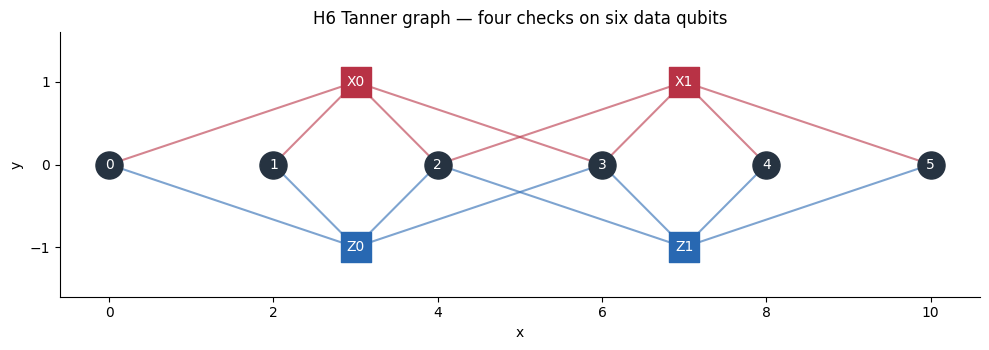

In [3]:
fig, ax = plt.subplots(figsize=(10, 3.6))
colors = {"X": "#b83245", "Z": "#2868b2"}
for basis in ("X", "Z"):
    checks = [s for s in patch.stabilizers if s["type"] == basis]
    for slot, s in enumerate(checks):
        sx, sy = patch.qubit_coords[s["syn_idx"]]
        for q in s["data_indices"]:
            x, y = patch.qubit_coords[q]
            ax.plot([sx, x], [sy, y], color=colors[basis], alpha=.6, lw=1.5)
        ax.scatter(sx, sy, marker="s", s=440, color=colors[basis], zorder=3)
        ax.text(sx, sy, f"{basis}{slot}", color="white", ha="center", va="center", zorder=4)
for q in sorted(patch.data_indices):
    x, y = patch.qubit_coords[q]
    ax.scatter(x, y, s=380, color="#263341", zorder=3)
    ax.text(x, y, str(q), color="white", ha="center", va="center", zorder=4)
ax.set(xlim=(-.6, 10.6), ylim=(-1.6, 1.6), xlabel="x", ylabel="y",
       title="H6 Tanner graph — four checks on six data qubits")
ax.set_xticks(range(0, 11, 2))
ax.set_yticks([-1, 0, 1])
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

## 3. Bare X/Z memory and automatic detectors

The six data qubits start in a product state in the memory basis. The first
extraction projects the initially unfixed checks. Later rounds compare check
outcomes, and final data readout supplies the matching boundary checks.
`CircuitBuilder` and `SyndromeTracker` construct detectors and both logical
observables automatically.

For three rounds the circuit has 10 qubits, 12 detectors, and 2 observables.

In [4]:
circuits = {}
for basis in ("Z", "X"):
    c = MemoryExperiment(qec_patch=HSixCode(), rounds=3, basis=basis).build()
    dets, obs = c.compile_detector_sampler(seed=98).sample(256, separate_observables=True)
    assert c.num_observables == 2 and c.num_detectors == 12
    assert not dets.any() and not obs.any()
    c.detector_error_model()
    print(f"{basis}: qubits={c.num_qubits}, detectors={c.num_detectors}, "
          f"observables={c.num_observables}; noiseless checks passed")
    circuits[basis] = c

Z: qubits=10, detectors=12, observables=2; noiseless checks passed
X: qubits=10, detectors=12, observables=2; noiseless checks passed


### Detector slices

This small view shows detector support during extraction. In Z memory,
first-round and final-readout boundaries constrain Z checks; interior rounds
compare both X and Z checks.

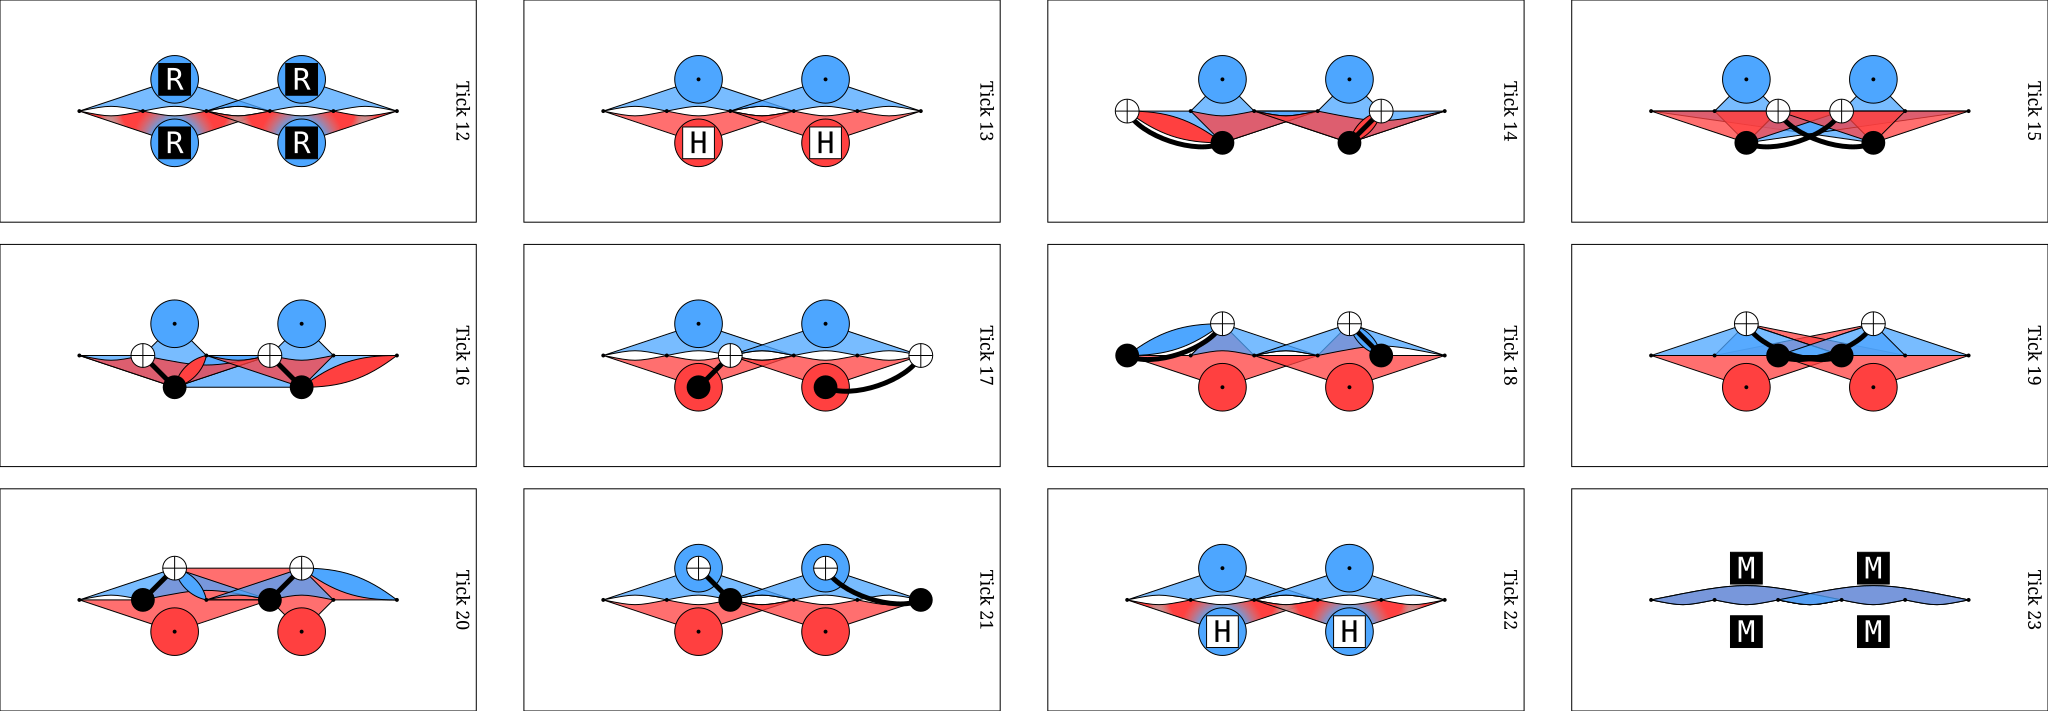

In [5]:
from IPython.display import SVG, display
display(SVG(str(circuits["Z"].diagram("detslice-with-ops-svg", tick=range(12, 24)))))

## 4. Circuit fault distance: lower and upper bounds

Use independent Pauli gate/SPAM noise with
`p_1q = p_2q = p_meas = p_reset = p` and `p_idle = 0`.

The **undecomposed DEM** preserves all single-fault signatures, including
hyperedges. There must be no term that flips a logical without a detector.
This proves a lower bound of two under the specified noise model.
A graphlike two-fault witness with independent physical locations provides
the matching upper bound. Default graphlike search alone skips hyperedges;
`ignore_ungraphlike_errors=False` attempts decomposition and is not an
exhaustive hyperedge search.

In [6]:
p = 0.008
noisy_circuits = {}
for basis in ("Z", "X"):
    c = MemoryExperiment(
        qec_patch=HSixCode(), rounds=2, basis=basis,
        noise_params=NoiseConfig(p_1q=p, p_2q=p, p_meas=p, p_reset=p, p_idle=0),
        noise_model="circuit_level",
    ).build()
    errors = [e for e in c.detector_error_model(decompose_errors=False).flattened()
              if e.type == "error"]
    undetected = [e for e in errors
                  if any(t.is_logical_observable_id() for t in e.targets_copy())
                  and not any(t.is_relative_detector_id() for t in e.targets_copy())]
    assert errors and not undetected
    witness = c.shortest_graphlike_error(canonicalize_circuit_errors=True)
    assert len(witness) == 2 and all(e.circuit_error_locations for e in witness)
    a, b = [e.circuit_error_locations[0] for e in witness]
    if a.stack_frames == b.stack_frames:
        ta, tb = a.instruction_targets, b.instruction_targets
        assert (ta.target_range_end <= tb.target_range_start
                or tb.target_range_end <= ta.target_range_start)
    print(f"{basis}: {len(errors)} nontrivial DEM signatures; "
          "undetected single faults=0; independent two-fault witness found")
    noisy_circuits[basis] = c

Z: 85 nontrivial DEM signatures; undetected single faults=0; independent two-fault witness found
X: 85 nontrivial DEM signatures; undetected single faults=0; independent two-fault witness found


## 5. Acceptance and conditional block error

Accept a shot only if **every detector** is zero, including final readout
checks. Count an accepted shot as a failure if **either logical observable**
flips. This is an error-detecting memory result without a decoder; no special
flag postselection tags are present in this baseline.

The following is a small single-p sample, not a slope estimate. A reproducible
four-p sweep lives in `tests/test_H_six_fault_distance.py` (slow tests).

In [7]:
shots = 100_000
for basis, c in noisy_circuits.items():
    dets, obs = c.compile_detector_sampler(seed=1098).sample(shots, separate_observables=True)
    accepted = ~dets.any(axis=1)
    n_accepted = int(accepted.sum())
    assert n_accepted > 0
    failures = int(obs[accepted].any(axis=1).sum())
    print(f"{basis}: p={p:g}, shots={shots}, accepted={n_accepted} "
          f"({n_accepted / shots:.2%}), failures={failures}, "
          f"conditional block error={failures / n_accepted:.6g}")

Z: p=0.008, shots=100000, accepted=61482 (61.48%), failures=75, conditional block error=0.00121987
X: p=0.008, shots=100000, accepted=61387 (61.39%), failures=62, conditional block error=0.00100999


## 6. What this establishes

For this memory schedule, excluding single faults and exhibiting two faults
explains quadratic conditional error as `p` approaches zero. The 400,000-shot
four-p regression sweep gave fitted slopes **Z: 2.0607, X: 1.9817** (Stim 1.15.0;
exact samples can differ across versions or platforms).

These checks concern a destructively measured memory experiment. A reusable
flagged encoder, Magic-H6 proxy, concatenation, and true non-Clifford
output-state validation each require their own acceptance and error criteria.

Run from the repository root with the LightStim virtual environment:

```bash
PYTHONPATH=. venv/bin/python -m pytest tests/test_H_six_fault_distance.py -m slow -s
```